## **Retrieval-Augmented Generation (RAG) Pipeline**

## 🔍 **What is Retrieval-Augmented Generation (RAG)?**

Large Language Models (LLMs) are powerful but they have two problems:
1. They **forget facts** (limited by training data cutoff).
2. They sometimes **hallucinate answers**.

RAG solves this by combining two steps:
- **Retriever (ChromaDB)**: Finds the most relevant chunks of your documents (knowledge base).
- **Generator (LLM, e.g. Gemini)**: Reads both the user's question + retrieved chunks, then produces an answer.

👉 This lets you ask **knowledge-base-grounded questions** instead of relying on the LLM's broad training.

  **Basic RAG Pipeline**

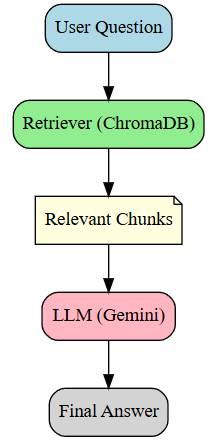

Today we will build a basic RAG pipeline in 3 steps:

1. Load and split documents

2. Store them in a vector database (Chroma)

3. Ask questions with retrieval + LLM

### **1. Install Dependencies**

Ensures all required Python packages (LangChain, ChromaDB, embeddings, LLM integration) are available. Fixes Colab-specific version conflicts.

In [1]:
# --- Install Python packages ---
!pip install --quiet requests==2.32.4 google-generativeai==0.8.5 google-ai-generativelanguage==0.6.15
!pip install langchain langchain-community langchain-huggingface langchain-chroma langchain-google-genai
!pip install sentence-transformers pypdf gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 k

### **2. Load a Simple Document**
Reads your PDF or other files into a standard format (Document objects) so they can be processed and embedded.

In [2]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("/content/HBR_How_Apple_Is_Organized_For_Innovation-4.pdf")
documents = loader.load()

print(f"✅ Loaded {len(documents)} page(s)")
print("\n📄 Preview of first page:\n")
print(documents[0].page_content[:300], "...")

✅ Loaded 11 page(s)

📄 Preview of first page:

REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLEORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Furthe ...


### **3. Split into Chunks**

Breaks large documents into smaller, manageable pieces. Chunking preserves context and helps retrieval accuracy.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = splitter.split_documents(documents)

print(f"✅ Split into {len(docs)} chunks")
print("\n📄 Preview of first chunk:\n")
print(docs[0].page_content[:500], "...")

✅ Split into 92 chunks

📄 Preview of first chunk:

REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLEORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted. ...


### **4. Embed + Store in Chroma**
Converts each text chunk into a vector representation. ChromaDB stores vectors for fast similarity search.

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# Select an embedding model. Here, we will use HuggingFace embedding model (https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Initialize the vector store and populate it with vectorized data (e.g., embeddings from text chunks)
vector_store = Chroma.from_documents(
    documents=docs,
    collection_name="demo_collection",
    embedding=embeddings,
    persist_directory="./chroma_db"   # Save it to disk or a database so it can be reloaded later
)

print("✅ Vector store created successfully!")
print(f"Stored {vector_store._collection.count()} chunks in Chroma")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Vector store created successfully!
Stored 92 chunks in Chroma


### **5. Connect Retriever + LLM**

Sets up the RAG pipeline: retriever finds relevant chunks, LLM reads them and the user query to generate an answer.

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from operator import itemgetter

# RAG requires a generative model to produce the final answer. Here, we will use Gemini-2.5-Flash
api_key = userdata.get("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=api_key)

retriever = vector_store.as_retriever(search_kwargs={"k": 10})

template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

qa = (
    {"context": itemgetter("query") | retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("✅ RAG pipeline ready!")

✅ RAG pipeline ready!


### **6. Try Queries**

Students can try questions and see how RAG pulls knowledge from the documents. Also allows comparison with LLM-only answers.

In [6]:
query = "What is this document about?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: What is this document about?
💡 RAG Answer: This document is an article from the Harvard Business Review (November–December 2020) that discusses Roger Rosner, Apple's VP of applications. It details his discretionary leadership, his portfolio of responsibilities (including News, UI design, software architecture, Keynote, and Pages), and the challenges he faced with expanding activities beyond his original expertise, such as learning about publishing news content via an app. It also touches on how Apple is organized for innovation.

🤔 Question: What is this document about?
🗣️ LLM-only Answer: I cannot see any document. Please provide the text, a link, or a description of the document you are referring to, and I'll be happy to tell you what it's about!


In [7]:
query = "What are the 3 key leadership characteristics expected by Steve Jobs?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: What are the 3 key leadership characteristics expected by Steve Jobs?
💡 RAG Answer: Since Steve Jobs implemented the functional organization, Apple's managers at every level have been expected to possess three key leadership characteristics:
1.  **Deep expertise** that allows them to meaningfully engage in all the work being done within their individual functions.
2.  **Immersion in the details** of those functions.
3.  **A willingness to collaboratively debate** other functions during collective decision-making.

🤔 Question: What are the 3 key leadership characteristics expected by Steve Jobs?
🗣️ LLM-only Answer: Steve Jobs was known for his incredibly high standards and a demanding leadership style that pushed people to achieve what they thought was impossible. Based on his career and how he led Apple, here are three key leadership characteristics he expected:

1.  **Uncompromising Pursuit of Excellence and Perfection:** Jobs had an almost obsessive attention to detail a

In [8]:
query = "Who is Paul Hubel?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: Who is Paul Hubel?
💡 RAG Answer: Paul Hubel is a senior leader who played a central role in the portrait mode effort. He and his team took a significant risk with this effort, particularly regarding the camera's cost and user willingness to pay a premium. He also thought that a dual-lens design with advanced features could enable photos similar to those taken by single-lens reflex cameras. He admitted that delaying the launch of the portrait mode for a year was "a hard pill to swallow."

🤔 Question: Who is Paul Hubel?
🗣️ LLM-only Answer: It seems there might be a slight confusion regarding the name.

The name **Paul Hubel** is not widely recognized as a prominent figure in science, especially not in the context of major discoveries like the Q-cycle or Nobel Prizes.

It's possible you might be thinking of one of the following scientists, who are famous for related work:

1.  **Peter D. Mitchell:** He was a British biochemist who was awarded the Nobel Prize in Chemistry in 1

### **7. Deploy in Gradio**

### **Exercises**

Encourages students to tweak chunk size, overlap, top-k retrieval, and embeddings to see how performance changes.

* **Change chunk_size and chunk_overlap** → try 1000 with overlap 200.

* **Change** k → try k=1 vs k=5.

* **Compare RAG vs. LLM-only answers.**

### **8. Appendix**

In [9]:
import gradio as gr

def compare_answers(user_query):
    # Get RAG answer
    rag_response = qa.invoke({"query": user_query})
    rag_answer = rag_response

    # Get LLM-only answer
    llm_response = llm.invoke(user_query)
    llm_answer = llm_response.content

    return rag_answer, llm_answer

with gr.Blocks() as demo:
    gr.Markdown("## 🔍 RAG vs LLM-only Answer Comparison")

    query_input = gr.Textbox(label="Enter your question", placeholder="Type any question here...", lines=1)
    submit_btn = gr.Button("Ask")

    rag_output = gr.Textbox(label="💡 RAG Answer", lines=5)
    llm_output = gr.Textbox(label="🗣️ LLM-only Answer", lines=5)

    submit_btn.click(fn=compare_answers, inputs=query_input, outputs=[rag_output, llm_output])
    query_input.submit(fn=compare_answers, inputs=query_input, outputs=[rag_output, llm_output])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f46021b3b2f111805.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
